In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

# IRIS

In [3]:
IRIS_FILE = "../data/iris.csv"

In [4]:
from utils import load_data
D, L, labels = load_data(IRIS_FILE)

## PCA

In [5]:
M = 2

In [6]:
from utils import get_cov
C = get_cov(D)
print("Covariance Matrix: ")
print(C)

Covariance Matrix: 
[[ 0.68112222 -0.04215111  1.26582     0.51282889]
 [-0.04215111  0.18871289 -0.32745867 -0.12082844]
 [ 1.26582    -0.32745867  3.09550267  1.286972  ]
 [ 0.51282889 -0.12082844  1.286972    0.57713289]]


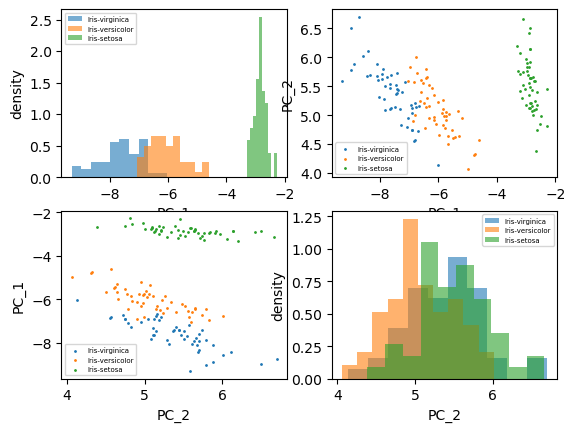

In [ ]:
from utils import get_PCs, plot_feature_pairs

PCs = get_PCs(D, m=M)
Dp_pca = np.dot(PCs.T, D) # Project Data
feature_names = [f'PC_{i}' for i in range(1, M+1)]
plot_feature_pairs(Dp_pca, L, labels, feature_names)

## LDA

In [8]:
M = 2

In [9]:
from utils import get_class_covariances

Sb, Sw = get_class_covariances(D, L, labels)
print("Between class covariance Matrix (SB): ")
print(Sb)
print("Within Class Covariance Matrix (SW): ")
print(Sw)

Between class covariance Matrix (SB): 
[[ 0.42141422 -0.13301778  1.101656    0.47519556]
 [-0.13301778  0.07563289 -0.38159733 -0.15288444]
 [ 1.101656   -0.38159733  2.91401867  1.24516   ]
 [ 0.47519556 -0.15288444  1.24516     0.53608889]]
Within Class Covariance Matrix (SW): 
[[0.259708   0.09086667 0.164164   0.03763333]
 [0.09086667 0.11308    0.05413867 0.032056  ]
 [0.164164   0.05413867 0.181484   0.041812  ]
 [0.03763333 0.032056   0.041812   0.041044  ]]


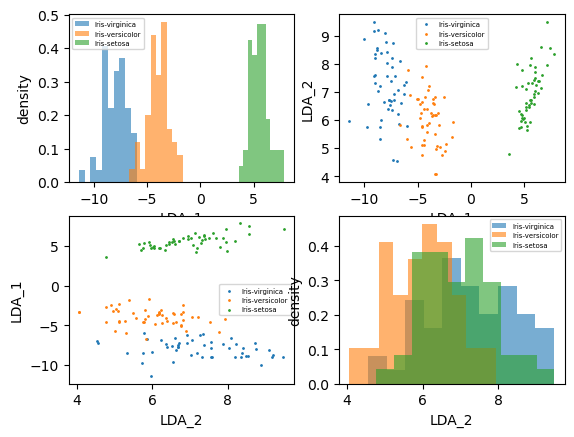

In [ ]:
from utils import get_LDs, plot_feature_pairs

W = get_LDs(D, L, labels, m=M)
Dp_lda = np.dot(W.T, D) # project data
feature_names = [f'LDA_{i}' for i in range(1, M+1)]
plot_feature_pairs(Dp_lda, L, labels, feature_names)

## Compare PCA and LDA

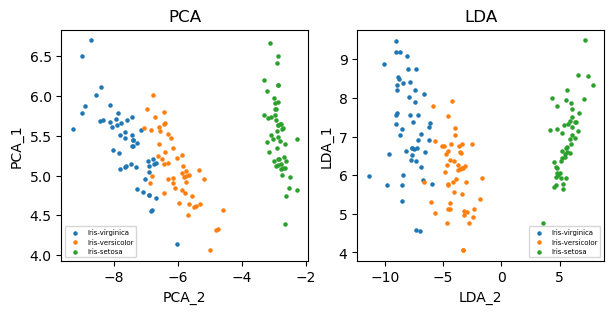

In [24]:
plt.figure(figsize=(7, 3))

plt.subplot(1, 2, 1)
plt.title("PCA")
for l in labels:
    samples = L[0] == l
    x = Dp_pca[0,samples]
    y = Dp_pca[1,samples]
    plt.scatter(x, y, label=l, s=5)
    plt.ylabel("PCA_1")
    plt.xlabel("PCA_2")
plt.legend(fontsize=5)


plt.subplot(1, 2, 2)
plt.title("LDA")
for l in labels:
    samples = L[0] == l
    x = Dp_lda[0,samples]
    y = Dp_lda[1,samples]
    plt.scatter(x, y, label=l, s=5)
    plt.ylabel("LDA_1")
    plt.xlabel("LDA_2")
plt.legend(fontsize=5)

plt.show()

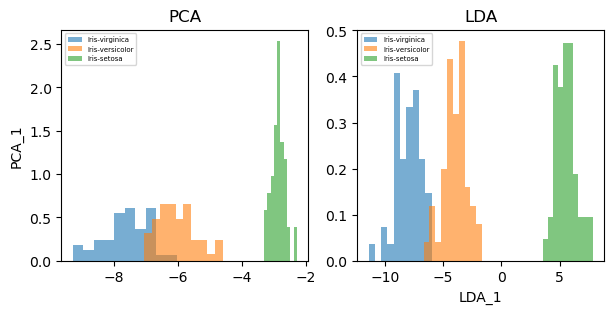

In [25]:
plt.figure(figsize=(7, 3))

plt.subplot(1, 2, 1)
plt.title("PCA")
for l in labels:
    samples = L[0] == l
    data = Dp_pca[0,samples]
    plt.hist(data, density=True, bins=10, histtype="barstacked", label=l, alpha=0.6)
    plt.ylabel("PCA_1")
plt.legend(fontsize=5)


plt.subplot(1, 2, 2)
plt.title("LDA")
for l in labels:
    samples = L[0] == l
    data = Dp_lda[0,samples]
    plt.hist(data, density=True, bins=10, histtype="barstacked", label=l, alpha=0.6)
    plt.xlabel("LDA_1")
plt.legend(fontsize=5)

plt.show()

## Classification with LDA + PCA

In [3]:
def load_iris():
    return sklearn.datasets.load_iris()['data'].T, sklearn.datasets.load_iris()['target']
DIris, LIris = load_iris()
D = DIris[:, LIris != 0]
L = LIris[LIris != 0]


In [4]:
from utils import split_db_2to1, vrow
(DTR, LTR), (DVAL, LVAL) = split_db_2to1(D, L)
LTR = vrow(LTR)
LVAL = vrow(LVAL)

labels = [1, 2]

In [5]:
from utils import get_LDs

W = get_LDs(DTR, LTR, labels, 1)
Dp_tr = np.dot(W.T, DTR)
Dp_val = np.dot(W.T, DVAL)

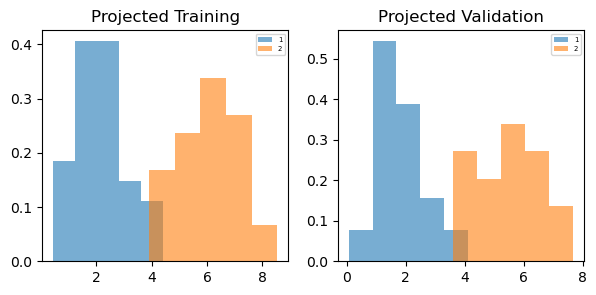

In [8]:
plt.figure(figsize=(7, 3))

plt.subplot(1, 2, 1)
plt.title("Projected Training")
for l in labels:
    samples = LTR[0] == l
    data = Dp_tr[0,samples]
    plt.hist(data, density=True, bins=5, histtype="barstacked", label=l, alpha=0.6)
plt.legend(fontsize=5)


plt.subplot(1, 2, 2)
plt.title("Projected Validation")
for l in labels:
    samples = LVAL[0] == l
    data = Dp_val[0,samples]
    plt.hist(data, density=True, bins=5, histtype="barstacked", label=l, alpha=0.6)
plt.legend(fontsize=5)

plt.show()

In [9]:
threshold = (Dp_tr[0, LTR[0]==1].mean() + Dp_tr[0, LTR[0]==2].mean()) / 2.0

In [ ]:
PVAL = np.zeros(shape=LVAL.shape[0], dtype=np.int32)
PVAL[Dp_val[0] >= threshold] = 2
PVAL[Dp_val[0] < threshold] = 1
